# Loan Approval Prediction

Start notebook for data exploration, dataset building, feature engineering, modeling, and evaluation.

In [3]:
# import liabraries 
import pandas as pd 
import numpy as np 

from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler 
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report

from sklearn.ensemble import RandomForestClassifier

In [10]:
df=pd.read_csv('../data/raw/loans_modified.csv')
df.head()


,loan_id,gender,married,dependents,education,self_employed,applicant_income,coapplicant_income,loan_amount,loan_amount_term,credit_history,property_area,loan_status
0,LP001003,Male,Yes,1,Graduate,No,4583.0,1508.0,128.0,360.0,1.0,Rural,0.0
1,LP001005,Male,Yes,0,Graduate,NaN,3000.0,0.0,66.0,360.0,1.0,Urban,1.0
2,LP001006,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.0,360.0,1.0,Urban,1.0
3,LP001008,Male,No,0,Graduate,No,6000.0,0.0,141.0,360.0,1.0,Urban,1.0
4,LP001011,Male,Yes,2,Graduate,Yes,5417.0,4196.0,267.0,360.0,1.0,Urban,1.0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 563 entries, 0 to 562
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   loan_id             534 non-null    object 
 1   gender              534 non-null    object 
 2   married             544 non-null    object 
 3   dependents          531 non-null    object 
 4   education           541 non-null    object 
 5   self_employed       529 non-null    object 
 6   applicant_income    537 non-null    float64
 7   coapplicant_income  529 non-null    float64
 8   loan_amount         533 non-null    float64
 9   loan_amount_term    535 non-null    float64
 10  credit_history      541 non-null    float64
 11  property_area       542 non-null    object 
 12  loan_status         535 non-null    float64
dtypes: float64(6), object(7)
memory usage: 57.3+ KB


In [18]:
df.isnull().mean() * 100


loan_id               5.150977
gender                5.150977
married               3.374778
dependents            5.683837
education             3.907638
self_employed         6.039076
applicant_income      4.618117
coapplicant_income    6.039076
loan_amount           5.328597
loan_amount_term      4.973357
credit_history        3.907638
property_area         3.730018
loan_status           4.973357
dtype: float64

In [21]:
df.duplicated().sum()

np.int64(25)

In [28]:
df=df.drop_duplicates().reset_index(drop=True)

In [29]:
df.duplicated().sum()

np.int64(0)

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 538 entries, 0 to 537
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   loan_id             512 non-null    object 
 1   gender              511 non-null    object 
 2   married             519 non-null    object 
 3   dependents          508 non-null    object 
 4   education           517 non-null    object 
 5   self_employed       506 non-null    object 
 6   applicant_income    514 non-null    float64
 7   coapplicant_income  506 non-null    float64
 8   loan_amount         508 non-null    float64
 9   loan_amount_term    513 non-null    float64
 10  credit_history      516 non-null    float64
 11  property_area       518 non-null    object 
 12  loan_status         510 non-null    float64
dtypes: float64(6), object(7)
memory usage: 54.8+ KB


In [33]:
df.duplicated(subset=["loan_id"]).sum()

np.int64(25)

In [34]:
df[df.duplicated(subset=["loan_id"], keep=False)].sort_values("loan_id")


,loan_id,gender,married,dependents,education,self_employed,applicant_income,coapplicant_income,loan_amount,loan_amount_term,credit_history,property_area,loan_status
65,NaN,Male,NaN,3+,NaN,Yes,5266.0,1774.0,187.0,360.0,1.0,Semiurban,1.0
87,NaN,Male,Yes,2,Not Graduate,No,4288.0,3263.0,133.0,180.0,1.0,Urban,1.0
95,NaN,Female,Yes,0,Graduate,No,2929.0,2333.0,139.0,360.0,1.0,Semiurban,1.0
121,NaN,Male,Yes,0,Graduate,No,2698.0,2034.0,122.0,360.0,1.0,Semiurban,1.0
144,NaN,NaN,No,0,Graduate,No,2237.0,0.0,63.0,480.0,0.0,Semiurban,0.0
163,NaN,Male,No,0,Not Graduate,No,4885.0,0.0,48.0,360.0,1.0,Rural,1.0
165,NaN,Male,Yes,0,Not Graduate,No,6033.0,0.0,160.0,360.0,1.0,Urban,0.0
178,NaN,Male,No,0,Graduate,NaN,2479.0,0.0,59.0,360.0,1.0,Urban,1.0
187,NaN,Male,Yes,2,Graduate,NaN,5000.0,0.0,72.0,360.0,0.0,Semiurban,0.0
189,NaN,Male,Yes,0,Graduate,No,2221.0,0.0,60.0,360.0,0.0,Urban,0.0


In [36]:
df.isna().sum()

loan_id               26
gender                27
married               19
dependents            30
education             21
self_employed         32
applicant_income      24
coapplicant_income    32
loan_amount           30
loan_amount_term      25
credit_history        22
property_area         20
loan_status           28
dtype: int64

In [39]:
df=df.dropna(subset=["loan_status"]).reset_index(drop=True)

In [40]:
df.isna().sum()

loan_id               24
gender                23
married               19
dependents            29
education             20
self_employed         32
applicant_income      24
coapplicant_income    31
loan_amount           30
loan_amount_term      25
credit_history        20
property_area         19
loan_status            0
dtype: int64

In [41]:
df = df.drop(columns=["loan_id"])

In [43]:
df["loan_status"].value_counts(normalize=True)

loan_status
1.0    0.713725
0.0    0.286275
Name: proportion, dtype: float64

In [56]:
cat_cols = df.select_dtypes(include="object").columns
num_cols = df.select_dtypes(include="number").columns.drop("loan_status")

display(cat_cols)
display(num_cols)

Index(['gender', 'married', 'dependents', 'education', 'self_employed',
       'property_area'],
      dtype='object')

Index(['applicant_income', 'coapplicant_income', 'loan_amount',
       'loan_amount_term', 'credit_history'],
      dtype='object')

In [51]:
#check outliers in numerical columns
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col, len(outliers))

applicant_income 42
coapplicant_income 17
loan_amount 32
loan_amount_term 69
credit_history 61
loan_status 0


In [ ]:
%pip install seaborn

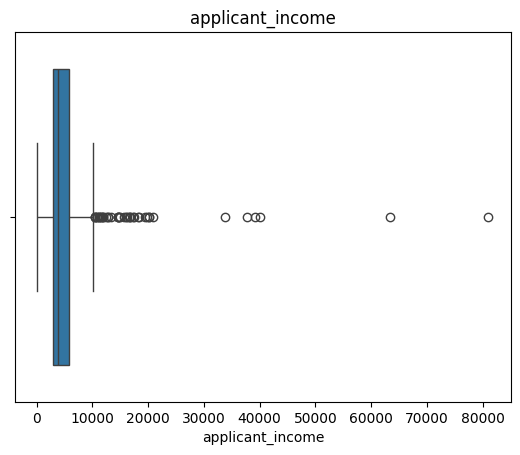

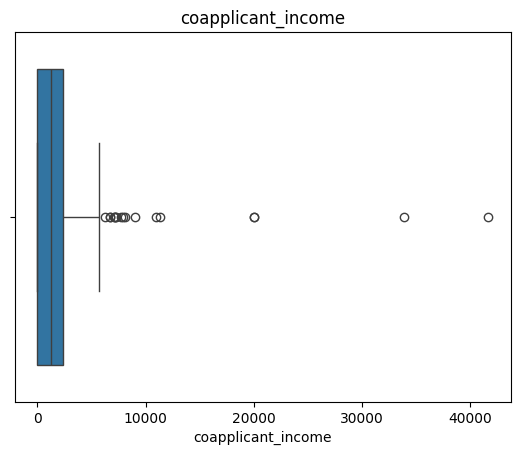

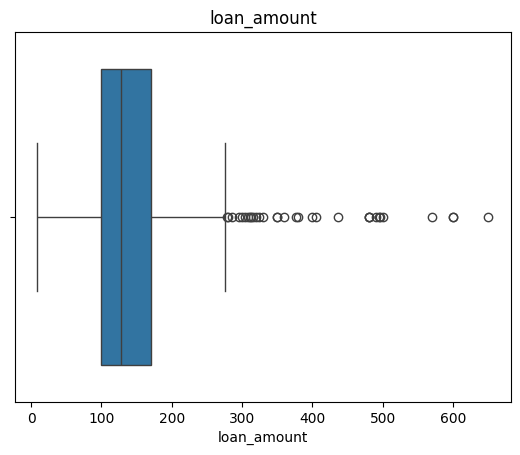

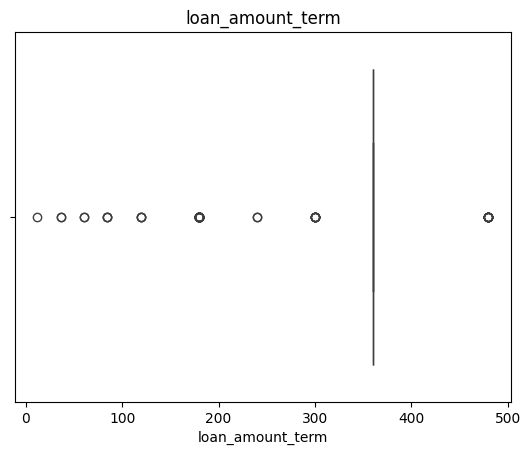

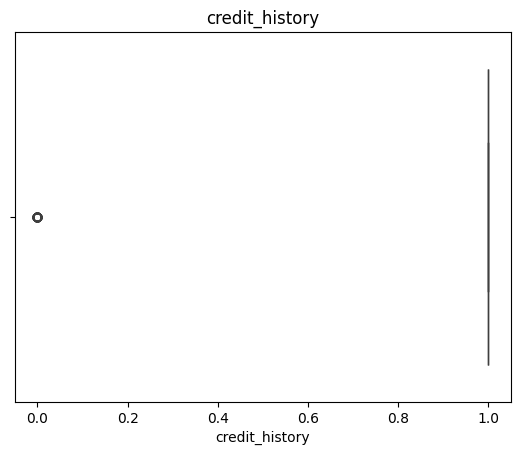

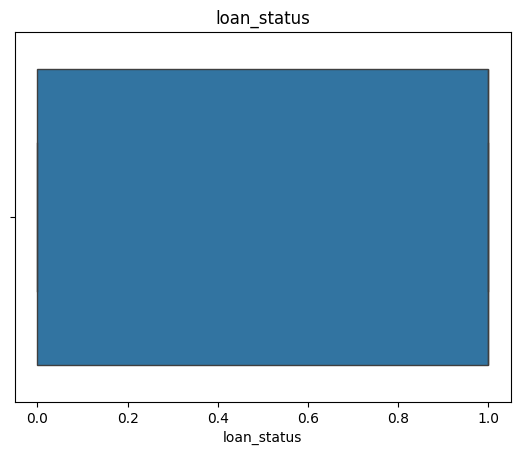

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [57]:
print("negative applicant_income:", len(df[df["applicant_income"] < 0]))
print("negative coapplicant_income:", len(df[df["coapplicant_income"] < 0]))
print("bad loan_amount:", len(df[df["loan_amount"] <= 0]))
print("bad loan_amount_term:", len(df[df["loan_amount_term"] <= 0]))


negative applicant_income: 0
negative coapplicant_income: 0
bad loan_amount: 0
bad loan_amount_term: 0


In [58]:
# traint test split
X = df.drop(columns=["loan_status"])
y = df["loan_status"]

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Preprocessing

In [61]:
display(X)
display(y)

,gender,married,dependents,education,self_employed,applicant_income,coapplicant_income,loan_amount,loan_amount_term,credit_history,property_area
0,Male,Yes,1,Graduate,No,4583.0,1508.0,128.0,360.0,1.0,Rural
1,Male,Yes,0,Graduate,NaN,3000.0,0.0,66.0,360.0,1.0,Urban
2,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.0,360.0,1.0,Urban
3,Male,No,0,Graduate,No,6000.0,0.0,141.0,360.0,1.0,Urban
4,Male,Yes,2,Graduate,Yes,5417.0,4196.0,267.0,360.0,1.0,Urban
...,...,...,...,...,...,...,...,...,...,...,...
505,Female,No,0,Graduate,No,2900.0,0.0,71.0,360.0,1.0,Rural
506,Male,Yes,3+,NaN,No,4106.0,0.0,40.0,180.0,1.0,Rural
507,Male,Yes,1,Graduate,No,8072.0,240.0,253.0,360.0,1.0,Urban
508,NaN,Yes,2,Graduate,NaN,7583.0,0.0,187.0,360.0,1.0,Urban


0      0.0
1      1.0
2      1.0
3      1.0
4      1.0
      ... 
505    1.0
506    1.0
507    1.0
508    1.0
509    1.0
Name: loan_status, Length: 510, dtype: float64

In [62]:
cat_cols=X_train.select_dtypes(include="object").columns
num_cols=X_train.select_dtypes(include="number").columns

In [63]:
#numeric pipeline
num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])

In [65]:
#categorical pipeline
cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

In [66]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_cols),
        ("cat", cat_transformer, cat_cols)
    ]
)

In [77]:
# pipeline helps avoid data leakage and keeps preprocessing steps organized and consistent during training and testing. It ensures that the same transformations are applied to both the training and test data, preventing data leakage and improving model performance.
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42, class_weight="balanced"))
])

In [78]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring=["accuracy", "balanced_accuracy", "f1_macro", "recall_macro"],
    return_train_score=True
)

pd.DataFrame(cv_results).mean()

fit_time                   0.054400
score_time                 0.006947
test_accuracy              0.798946
train_accuracy             1.000000
test_balanced_accuracy     0.684797
train_balanced_accuracy    1.000000
test_f1_macro              0.704258
train_f1_macro             1.000000
test_recall_macro          0.684797
train_recall_macro         1.000000
dtype: float64

In [79]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  Index(['applicant_income', 'coapplicant_income', 'loan_amount',
       'loan_amount_term', 'credit_history'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['gender', 'married', 'dependents', 'education', 'self_employed',
       'property_area'],
      dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

In [80]:
y_pred = model.predict(X_test)

In [81]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))    

Accuracy: 0.8235294117647058
Classification Report:
               precision    recall  f1-score   support

         0.0       0.76      0.55      0.64        29
         1.0       0.84      0.93      0.88        73

    accuracy                           0.82       102
   macro avg       0.80      0.74      0.76       102
weighted avg       0.82      0.82      0.81       102

